# Praktikum 4 (Woche 5), lineare Ausgleichsrechnung
In diesem Praktikum werden zwei lineare Ausgleichsprobleme unter Verwendung der **Normalgleichungen** mit Hilfe der **Cholesky-Zerlegung** gelöst.

## Aufgabe 1
Als Messdaten (File *data.txt*) sind Punkte

$$
    (t_i, y_i)
$$

in der Ebene gegeben. Diese sollen durch ein Modell der Form

$$
    y_i = \frac{a_0}{2} + \sum_{k=1}^{n} a_k \cdot \cos(\omega\,k\,t) + b_k \cdot \sin(\omega\,k\,t) 
$$

dargestellt werden, wobei 

$$ 
    \omega = \frac{2 \pi}{T} = 1
$$

Bestimmen Sie die Koeffizienten $a_k, b_k$ für das Modell mit $n = 5$.

* Lösen Sie die Normalgleichungen mit Hilfe der Cholesky-Zerlegung aus Praktikum 3b.
* Bestimmen Sie die Fehlerquadratsumme
* Erstellen Sie einen plot der Daten zusammen mit dem gefitteten Modell
* **Optional:** vergleichen Sie die Ergebnisse mit der diskreten Fouriertransformation


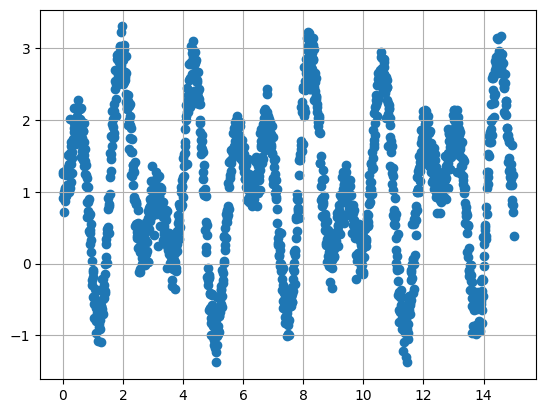

In [123]:
import numpy as np 
import matplotlib.pyplot as plt

# Daten (t, y) aus Textfile importieren
data = np.genfromtxt('NUM1_Praktikum_W5_data.txt')
t, y = data.T

plt.scatter(t, y)
plt.grid()

T = 2*np.pi # Periode 

In [124]:
def mychol(A):
    n = A.shape[0]
    L = np.zeros_like(A)
    
    for k in range(n):
        L[k,k] = np.sqrt(A[k,k])
        l = A[k+1:,k] / L[k,k]
        L[k+1:,k] = l
        A[k+1:,k+1:] -= np.outer(l, l)
        
    return L

Fehlerquadratsumme: 59.25967059898787


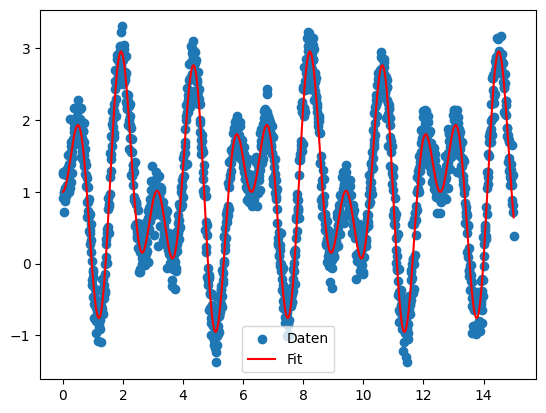

In [125]:
n = 5
m = len(t) 


A = np.zeros((m, 1+2*n)) # matrix erstellen, 

A[:,0] = 0.5 ## das sind die a0


#Matrix
for k in range(1, n+1): ##matrix einsortieren
    A[:, 2*k-1] = np.cos(k*t)
    A[:, 2*k] = np.sin(k*t)

# Normalengleichungen
AtA = A.T @ A
Aty = A.T @ y



### GLEICHUNGSSYSTEM LÖSEN:

#CHOLESKY CALL!
L = mychol(AtA)


#Vorwärts EINSETZEN
z = np.linalg.solve(L, Aty)
#Rückwärts EINSETZEN
x = np.linalg.solve(L.T, z)

y_fit = A @ x ### alte y werte berechnen aus MAtrix mal Vektor -> Vektor

# Fehler
error = np.sum((y - y_fit)**2)
print("Fehlerquadratsumme:", error)

# Plot
plt.scatter(t, y, label="Daten")
plt.plot(t, y_fit, color='red', label="Fit")
plt.legend()
plt.show()


## Aufgabe 2
Gegeben ist die Entladungskurve 

$$
    U(t) = U_0 \cdot \exp \left( - \frac{t}{R C} \right)
$$

eines Kondensators mit bekanntem Innenwiderstand $R = 100 \Omega$.

| t[ms] | U |
| --- | --- |
| 0 | 5.0 |
| 0.03 | 2.94 |
| 0.05 | 1.73 |
| 0.08 | 1.01 |
| 0.10 | 0.60 |

* Lösen Sie die Normalgleichungen des linearen Ausgleichsproblems in zwei Varianten:  
 a) indem Sie U0 als Parameter des Modells auffassen - dann enthält das Modell zwei Parameter  
 b) indem Sie U0 = U(0) = 5.0 direkt übernehmen - dann enthält das Modell nur noch einen einzigen Parameter    
* Erstellen Sie einen Plot der Messdaten, zusammen mit dem gefitteten Modell
* Dokumentieren Sie kurz, wie Sie aus dem Auslgleichsproblem ein *lineares* Ausgleichsproblem machen.


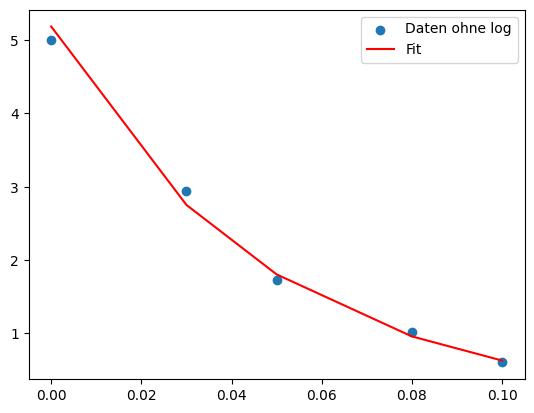

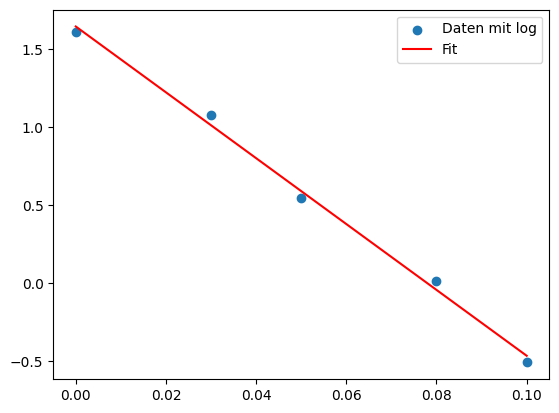

In [126]:
t = np.array([0,0.03,0.05,0.08,0.1])
U = np.array([5,2.94,1.73,1.01, 0.60])

A = np.zeros((5, 2)) # matrix erstellen, 

### AUFGABE A
y = U ## spanungen abhängig t
###MATRIX FüLLEN: mit 1ern, und dann die 2te spalte mit den t werten kopiert
A[:,0] = 1 ## das sind die 1 in der ersten spalte
A[:, 1] = t


# Normalengleichungen
AtA = A.T @ A
Aty = A.T @ np.log(y)


### GLEICHUNGSSYSTEM LÖSEN:

#CHOLESKY CALL!
L = mychol(AtA)


#Vorwärts EINSETZEN
z = np.linalg.solve(L, Aty)
#Rückwärts EINSETZEN
x = np.linalg.solve(L.T, z)

y_fit = A @ x ### alte y werte berechnen aus MAtrix mal Vektor -> Vektor


# Plot ohne log
plt.scatter(t, y, label="Daten ohne log")
plt.plot(t, np.exp(y_fit), color='red', label="Fit")
plt.legend()
plt.show()
###plt.scatter(t, U)

# Plot mit log skaliert
plt.scatter(t, np.log(y), label="Daten mit log")
plt.plot(t, y_fit, color='red', label="Fit")
plt.legend()
plt.show()
